# Évaluation des Modèles

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from src.evaluation.evaluator import TimeSeriesEvaluator
from src.models.prophet import ProphetRegressor
from src.models.fourier import FourierRegressor
from src.models.baselines import \
    AverageRegressor, LastWeekRegressor, YesterdayRegressor, LinearRegressor, SimilarDayRegressor
from src.models.xgboost.xgboost_regressor import XGBoostRegressor

df = pd.read_csv('../data/processed/dataset_final.csv')

Importing plotly failed. Interactive plots will not work.


In [2]:
evaluator = TimeSeriesEvaluator(df, "perfect")

val_start = pd.to_datetime('2024-01-01').tz_localize('Europe/Paris')
test_start = pd.to_datetime('2025-01-01').tz_localize('Europe/Paris')

df_train, df_val, df_test = evaluator.split_data(val_start, test_start, load_existing_splits=True)

## 3. Modèles de Références

In [3]:
evaluator.grid_search_rolling_validation(AverageRegressor, [{}])

evaluator.grid_search_rolling_validation(LastWeekRegressor, [{}])

evaluator.grid_search_rolling_validation(YesterdayRegressor, [{}])

evaluator.grid_search_rolling_validation(
    SimilarDayRegressor,
    {
		"k": [4],
		"temp_weight": [100.0, 1000.0]
	}
)

evaluator.grid_search_rolling_validation(
    LinearRegressor,
    [{"features_cols": [
        [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
	]
    ]}]
);

Grid Search de AverageRegressor :

Combination 1/1 : {}
Évaluation de AverageRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 9472.67 MW |RMSE = 11667.64 MW |MAPE = 18.67%


Validation : MAE = 8503.59 MW |RMSE = 10297.54 MW |MAPE = 18.26%

Best MAE sur Validation : 8503.59 MW
Best Params : {}

Grid Search de LastWeekRegressor :

Combination 1/1 : {}
Évaluation de LastWeekRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3603.55 MW |RMSE = 5263.36 MW |MAPE = 6.51%


Validation : MAE = 3229.23 MW |RMSE = 4845.62 MW |MAPE = 6.05%

Best MAE sur Validation : 3229.23 MW
Best Params : {}

Grid Search de YesterdayRegressor :

Combination 1/1 : {}
Évaluation de YesterdayRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 3564.69 MW |RMSE = 4973.78 MW |MAPE = 6.87%


Validation : MAE = 3182.98 MW |RMSE = 4362.14 MW |MAPE = 6.40%

KeyboardInterrupt: 

## 4. Fourier Regression

In [3]:
features_cols = [
    [
		'consommation_mw_meme_heure_derniere_connue',
        'consommation_mw_derniere_connue',
		'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366',
		'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances',
		'temperature_c_pondere_pop_meme_heure_derniere_connue',
		'temperature_c_pondere_pop_derniere_connue',
		'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366'
	]
]

best_params = evaluator.grid_search_rolling_validation(
    FourierRegressor,
    [{"features_cols": features_cols}]
);

evaluator.rolling_test(FourierRegressor(features_cols=features_cols[0]));

Grid Search de FourierRegressor :

Combination 1/1 : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semaine', 'jour_annee', 'mois', 'annee', 'weekend', 'ferie', 'vacances', 'temperature_c_pondere_pop_meme_heure_derniere_connue', 'temperature_c_pondere_pop_derniere_connue', 'temperature_c_pondere_pop_moins_365', 'temperature_c_pondere_pop_moins_366']}
Évaluation de FourierRegressor | 8784 lignes | réentraînement/6ME | 3 itérations
Progression: 2024-07-31 00:00...
Train : MAE = 1933.53 MW |RMSE = 2483.09 MW |MAPE = 3.80%


Validation : MAE = 1755.07 MW |RMSE = 2267.01 MW |MAPE = 3.63%

Best MAE sur Validation : 1755.07 MW
Best Params : {'features_cols': ['consommation_mw_meme_heure_derniere_connue', 'consommation_mw_derniere_connue', 'consommation_mw_moins_7', 'consommation_mw_moins_365', 'consommation_mw_moins_366', 'heure', 'jour_semai

## 5. Prophet

In [5]:
evaluator.grid_search_rolling_validation(
    ProphetRegressor,
    [{"features_cols": [
        [
			"temperature_c_pondere_pop_sous_15_derniere_connue", "temperature_c_pondere_pop_au_dessus_22_derniere_connue",
        ]
    ]}]
)

Grid Search de ProphetRegressor :

Combination 1/1 : {'features_cols': ['temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue']}
Évaluation de ProphetRegressor | 8784 lignes | réentraînement/6ME | 3 itérations


05:38:56 - cmdstanpy - INFO - Chain [1] start processing
05:39:22 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-01 00:00...

05:39:29 - cmdstanpy - INFO - Chain [1] start processing
05:39:52 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-01-31 00:00...

05:40:02 - cmdstanpy - INFO - Chain [1] start processing
05:40:39 - cmdstanpy - INFO - Chain [1] done processing


Progression: 2024-07-31 00:00...
Train : MAE = 153218.01 MW |RMSE = 274158.87 MW |MAPE = 298.86%


Validation : MAE = 27292.04 MW |RMSE = 38993.77 MW |MAPE = 60.29%

Best MAE sur Validation : 27292.04 MW
Best Params : {'features_cols': ['temperature_c_pondere_pop_sous_15_derniere_connue', 'temperature_c_pondere_pop_au_dessus_22_derniere_connue']}



[{'train_metrics': {'MAE': 153218.00835984896,
   'RMSE': 274158.8679796339,
   'MAPE': 298.86393643060666,
   'per_hour':                        MAE           RMSE
   cible_heure                              
   0            153067.274980  274552.751853
   1            153260.350542  274300.846490
   2            153257.658788  274033.596319
   3            153431.326526  274037.415175
   4            153389.804049  274048.722050
   5            153399.178100  274008.750314
   6            153269.949451  274092.094727
   7            153335.736774  274139.396938
   8            153278.810541  274187.942006
   9            153232.551687  274176.039526
   10           153232.381845  274181.236167
   11           153080.093550  274241.921390
   12           153161.610240  274181.551764
   13           153008.432057  274305.103626
   14           153083.956368  274248.110286
   15           153201.341896  274143.477386
   16           153217.220787  274097.974449
   17           153161.04

## 6. XGB

In [ ]:
evaluator.grid_search_rolling_validation(
    XGBoostRegressor,
    [{}]
);

## Visualisation

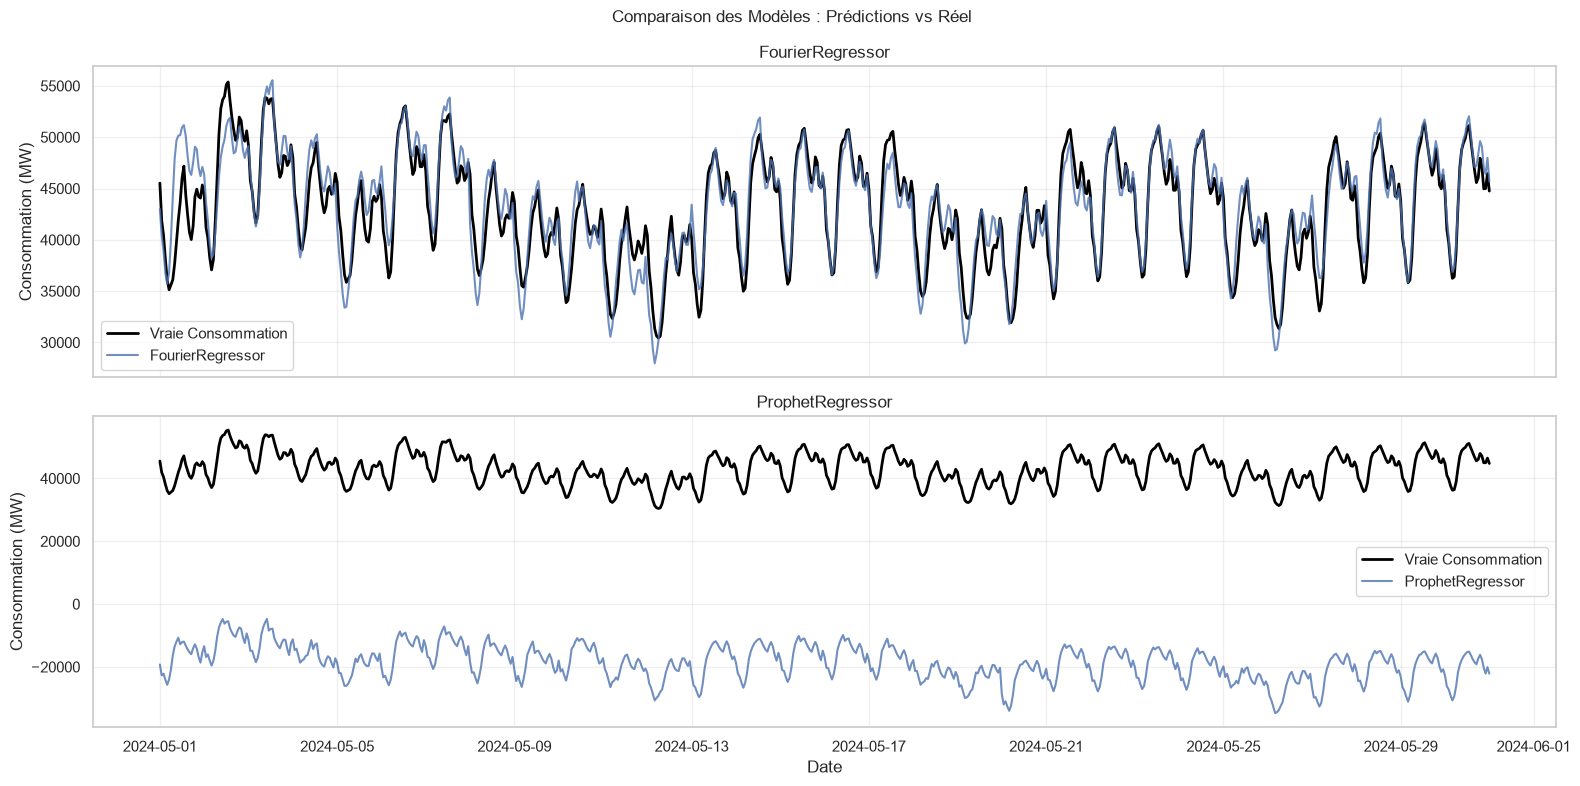

In [6]:
# Zoomons sur le mois de Mai 2024
start_zoom = pd.to_datetime('2024-05-01').tz_localize('Europe/Paris')
end_zoom = pd.to_datetime('2024-05-31').tz_localize('Europe/Paris')

evaluator.plot_predictions(use_test=False, start_date=start_zoom, end_date=end_zoom)

In [ ]:
evaluator.plot_feature_importances(top_n=15)

In [ ]:
evaluator.plot_train_val_test_metrics()

In [ ]:
evaluator.plot_error_per_horizon()